## import

In [77]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
import torchvision as tv
from torchvision.transforms import v2
import cv2
import matplotlib.pyplot as plt
import pygame
import random
from collections import deque

if torch.cuda.is_available():
    defDevice = torch.device('cuda')
    print('cuda available')
    # torch.set_default_device(torch.cuda.current_device())

cuda available


## load dataset

In [78]:
default_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32),
    v2.Lambda(lambda x: x.to(defDevice)),
])
class CustomData(Dataset):
    def __init__(self,testing:bool=False,proportion:float=1.0,transform=None,notebook_transform=None,path:str='./photos/dataset_final',notebook_path:str='./photos/notebook'):
        if not notebook_transform:
            self.notebook_transform = default_transform
        else:
            self.notebook_transform = v2.Compose([default_transform,notebook_transform])
        if not transform:
            transform = default_transform
        else:
            transform = v2.Compose([default_transform,transform])
        if testing:
            proportion = 1-proportion
        self.path = path
        self.notebook_path = notebook_path
        self.transform = transform
        self.labels = os.listdir(self.path)
        self.label_to_idx = {label: idx for idx, label in enumerate(self.labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}
        self.data=[]
        length = 0
        for label in self.labels:
            startIdx = 0 if not testing else int(proportion*len(os.listdir(f'{self.path}/{label}')))
            endIdx = int(proportion*len(os.listdir(f'{self.path}/{label}'))) if not testing else len(os.listdir(f'{self.path}/{label}'))
            for i in range(startIdx, endIdx):
                file = os.listdir(f'{self.path}/{label}')[i]
                self.data.append((f'{self.path}/{label}/{file}', label))
                length+=1
        self.length = length
        # random.shuffle(self.data) [dataLoader does this]
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        imgpos, label = self.data[idx]
        img = (cv2.imread(imgpos, cv2.IMREAD_GRAYSCALE))
        if self.transform:
            img = self.transform(img)
        if self.notebook_path:
            img = self.applyNotebook(img)
        return img, torch.tensor(self.label_to_idx[label],device=defDevice)
    def getLabel(self, idx:int|torch.Tensor)->str:
        if(type(idx)==torch.Tensor): 
            idx = idx.item()
        return self.idx_to_label[idx]
    def applyNotebook(self, img:torch.Tensor)->torch.Tensor:
        filepath = f'{self.notebook_path}/{random.choice(os.listdir(self.notebook_path))}'
        notebook_img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        notebook_img = self.notebook_transform(notebook_img)
        # print(img.shape)
        # print(notebook_img.shape)
        # alpha = random.uniform(0.001, 0.002)
        alpha = 0
        blend = img + alpha * notebook_img
        blend = torch.clamp(blend, 0, 1)
        return blend

## Data tranformations

### canny transforms (custom)

In [79]:
custom_transforms = v2.Compose([
    v2.RandomRotation(degrees=(-22,22),),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
])

nb_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32),
    v2.Lambda(lambda x: x.to(defDevice)),
    v2.RandomCrop(size=(120, 120)),
    v2.Resize(size=(120,120)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=(-22,22),),
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
])

### test dataset

In [80]:
mydata = CustomData(testing=False,transform=custom_transforms,notebook_transform=nb_transform)
print(len(mydata))

16220


torch.Size([1, 120, 120])
dc_volt_src_2_r3


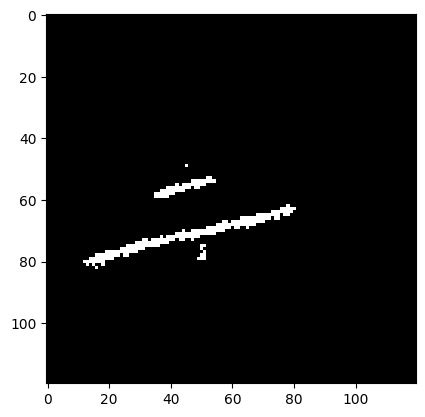

In [81]:
img,label = mydata[random.randint(0, len(mydata)-1)]
print(img.shape)
print(mydata.getLabel(label.item()))
plt.imshow(img.squeeze().cpu().numpy(), cmap='gray')

## Model

- 1 input layer for [28*28]

In [82]:
x = torch.zeros(1,1,120,120)
pool = nn.MaxPool2d(2,2)
x = pool(F.relu(nn.Conv2d(1,6,5,1)(x)))
x = pool(F.relu(nn.Conv2d(6,16,5,1)(x)))
x.shape

torch.Size([1, 16, 27, 27])

In [83]:
class Model(nn.Module):
    def __init__(self,model:nn.Sequential=None):
        super().__init__()
        self.model = model or nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),
            nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5,stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(16*27*27,256),
            nn.ReLU(),
            nn.Linear(256,120),
            nn.ReLU(),
            nn.Linear(120,45),
        )
    def forward(self,x):
        return self.model.forward(x)

### test model

In [84]:
# model = Model()
# print(list(model.parameters()))

## Training

In [85]:
model = Model().to(device=defDevice)
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
batchSize = 32
trainDataloader = DataLoader(CustomData(proportion=0.8, transform=custom_transforms,notebook_transform=nb_transform), batch_size=batchSize, shuffle=True)
testDataloader = DataLoader(CustomData(testing=True, proportion=0.2, transform=custom_transforms,notebook_transform=nb_transform), batch_size=batchSize, shuffle=True)
print(trainDataloader.dataset.length)
print(testDataloader.dataset.length)
losses = []
for epoch in range(15):
    model.train()
    total_loss = 0
    images=0
    correctPercent = 0
    for x,y in trainDataloader:
        images+=batchSize
        optimizer.zero_grad()
        yout = model(x)
        pred = torch.argmax(yout,dim=1)
        correctPercent+=(pred==y).sum()
        l = loss(yout,y)
        l.backward()
        optimizer.step()
        total_loss += l.item()
        print(f'epoch {epoch+1} loss:{l.item():.3e} images:{images/len(trainDataloader)/batchSize:.0%}'+' '*5,end='\r')
    losses.append(total_loss/len(trainDataloader))
    print(f'epoch {epoch+1} loss {total_loss/len(trainDataloader):.3e} correct {correctPercent/len(trainDataloader)/batchSize:.2%}'+' '*15)

12961
3259
epoch 1 loss 2.236e+00 correct 34.80%               
epoch 2 loss 1.165e+00 correct 60.97%               
epoch 3 loss 8.826e-01 correct 69.40%               
epoch 4 loss 7.506e-01 correct 73.59%               
epoch 5 loss 6.401e-01 correct 77.36%               
epoch 6 loss 5.943e-01 correct 78.94%               
epoch 7 loss 5.329e-01 correct 81.25%               
epoch 8 loss 4.794e-01 correct 83.07%               
epoch 9 loss 4.729e-01 correct 83.36%               
epoch 10 loss 4.295e-01 correct 84.98%               
epoch 11 loss 3.896e-01 correct 86.22%               
epoch 12 loss 3.671e-01 correct 87.03%               
epoch 13 loss 3.534e-01 correct 87.72%               
epoch 14 loss 3.263e-01 correct 88.79%               
epoch 15 loss 3.280e-01 correct 88.31%               


### plot loss

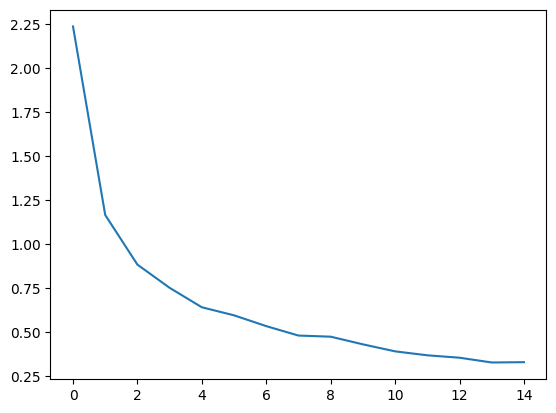

In [86]:
plt.plot(losses)

## Testing

torch.Size([1, 1, 120, 120])
dc_volt_src_2_r1
dc_volt_src_2_r1
6.433e-01


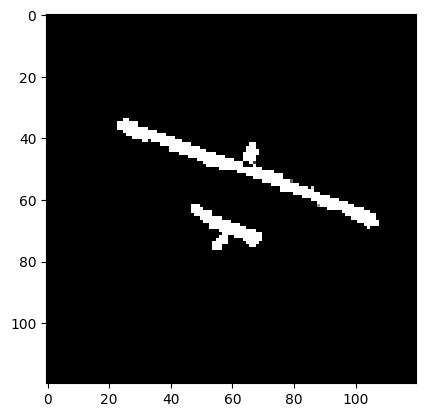

In [87]:
model.eval()
total_loss = 0
img,label = mydata[random.randint(0, len(mydata)-1)]
with torch.no_grad():
    img = img.unsqueeze(0)
    print(img.shape)
    print(mydata.getLabel(label))
    yout = model(img)
    pred = torch.argmax(yout)
    print(mydata.getLabel(pred))
plt.imshow(img.squeeze().cpu().numpy(), cmap='gray')
with(torch.no_grad()):
    for x,y in testDataloader:
        yout = model(x)
        total_loss += loss(yout,y).item()
total_loss /= len(testDataloader)
print(f'{total_loss:.3e}')

In [88]:
torch.save(model.state_dict(), "classificationModel.pth")


Overall Accuracy: 79.50%


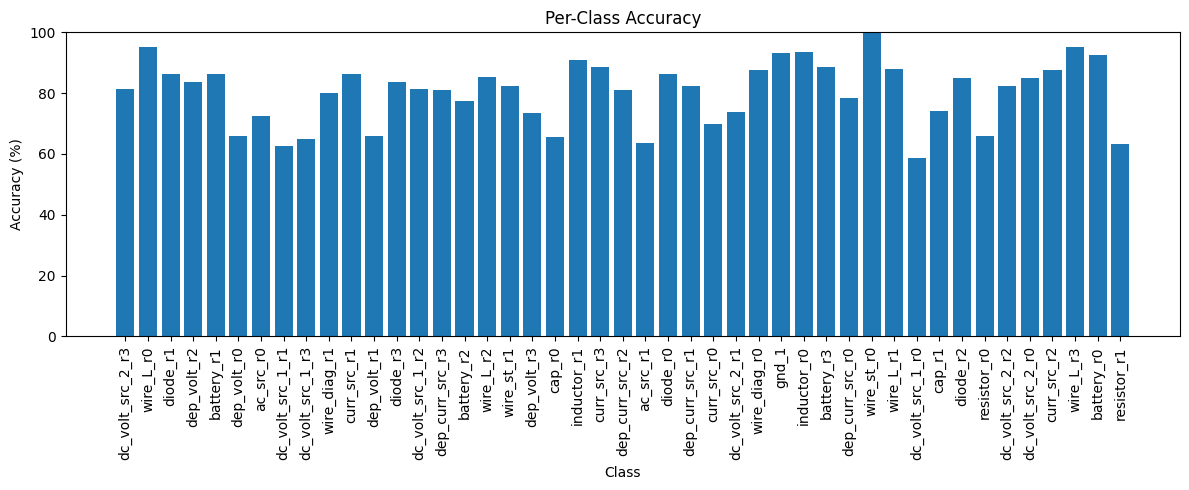

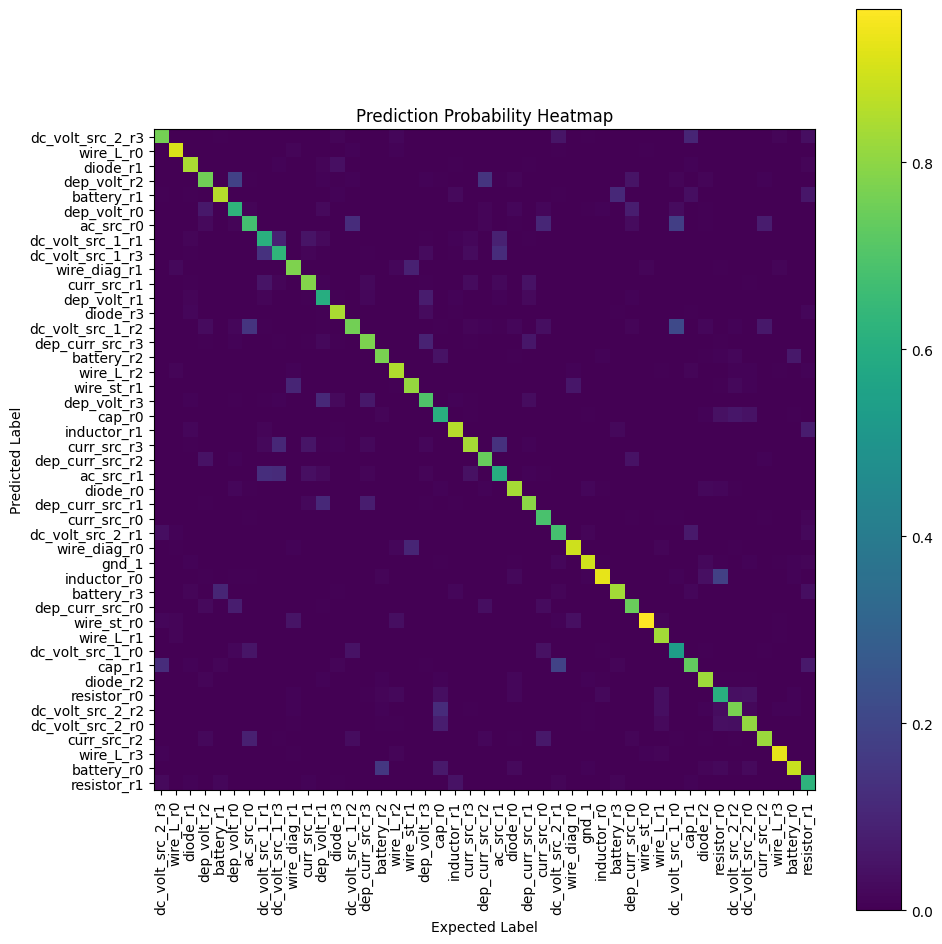

In [89]:
model.eval()

num_classes = len(mydata.labels)

# -----------------------------
# stats containers
# -----------------------------

correct = 0
total = 0

correct_per_class = torch.zeros(num_classes)
total_per_class = torch.zeros(num_classes)

prob_matrix = torch.zeros(
    (num_classes, num_classes)
)

count_per_class = torch.zeros(num_classes)

# -----------------------------
# evaluation loop
# -----------------------------

with torch.no_grad():

    for x, y in testDataloader:

        yout = model(x)

        probs = torch.softmax(yout, dim=1)

        preds = torch.argmax(probs, dim=1)

        # overall accuracy
        correct += (preds == y).sum().item()
        total += y.size(0)

        for true_label, pred_label, prob_vec in zip(
            y,
            preds,
            probs
        ):

            # histogram stats
            total_per_class[true_label] += 1

            if true_label == pred_label:
                correct_per_class[true_label] += 1

            # heatmap stats
            prob_matrix[:, true_label] += prob_vec.cpu()

            count_per_class[true_label] += 1

# -----------------------------
# final metrics
# -----------------------------

overall_accuracy = 100 * correct / total

accuracy_per_class = (
    correct_per_class / total_per_class
) * 100

prob_matrix /= count_per_class.unsqueeze(0)

accuracy_per_class = accuracy_per_class.numpy()
prob_matrix = prob_matrix.numpy()

# -----------------------------
# overall accuracy print
# -----------------------------

print(f"\nOverall Accuracy: {overall_accuracy:.2f}%")

# -----------------------------
# histogram
# -----------------------------

plt.figure(figsize=(12,5))

plt.bar(
    mydata.labels,
    accuracy_per_class
)

plt.xticks(rotation=90)

plt.ylabel("Accuracy (%)")
plt.xlabel("Class")

plt.title("Per-Class Accuracy")

plt.ylim(0,100)

plt.tight_layout()

plt.show()

# -----------------------------
# heatmap
# -----------------------------

plt.figure(figsize=(10,10))

im = plt.imshow(
    prob_matrix,
    cmap='viridis',
    interpolation='nearest'
)

plt.colorbar(im)

plt.xticks(
    range(num_classes),
    mydata.labels,
    rotation=90
)

plt.yticks(
    range(num_classes),
    mydata.labels
)

plt.xlabel("Expected Label")
plt.ylabel("Predicted Label")

plt.title("Prediction Probability Heatmap")


plt.tight_layout()

plt.show()

## Self-Test

### draw component

In [90]:
model = Model()
model.load_state_dict(torch.load("classificationModel.pth"))
model.to(device=defDevice)
model.eval()
pygame.init()
W,H = 240,240
screen = pygame.display.set_mode((W,H))
pygame.display.set_caption("CamPyCad")
clock = pygame.time.Clock()
screen.fill((0,0,0))
radius = 3
running = True
drawing = False
while(running):
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        if event.type == pygame.MOUSEBUTTONDOWN:
            drawing = True
        if event.type == pygame.MOUSEBUTTONUP:
            drawing = False
        if event.type == pygame.KEYDOWN:
            if event.key == pygame.K_c:
                screen.fill((0, 0, 0))
            if event.key == pygame.K_SPACE:
                drawImg = torch.tensor(pygame.surfarray.array3d(screen),dtype=torch.float32)
                drawImg = drawImg.mean(dim=2, keepdim=True)       # convert to grayscale (H, W, 1)
                drawImg = drawImg.permute(2, 0, 1).unsqueeze(0)
                drawImg = F.interpolate(drawImg, size=(120, 120), mode='bilinear', align_corners=False)
                drawImg = drawImg.to(defDevice)
                print(type(drawImg),drawImg.shape)
                with torch.no_grad():
                    yout = model(drawImg)
                    pred = torch.argmax(yout)
                    print(mydata.getLabel(pred))
        if (drawing):
            mx, my = pygame.mouse.get_pos()
            pygame.draw.circle(screen, (255, 255, 255), (mx, my), radius)
    pygame.display.flip()
    clock.tick(300)
pygame.quit()

### camera test

In [91]:
cv = cv2
# -------------------------
# load model
# -------------------------

model = Model()

model.load_state_dict(
    torch.load(
        "classificationModel.pth",
        map_location=defDevice
    )
)

model.to(defDevice)

model.eval()

# -------------------------
# helpers
# -------------------------

def rescale(
    frame,
    scale=0.75
):
    width = int(frame.shape[1] * scale)
    height = int(frame.shape[0] * scale)

    return cv.resize(
        frame,
        (width,height),
        interpolation=cv.INTER_AREA
    )

def change_brightness(
    img,
    value=30
):
    hsv = cv.cvtColor(
        img,
        cv.COLOR_BGR2HSV
    )

    h, s, v = cv.split(hsv)

    v = cv.add(v, value)

    v[v > 255] = 255
    v[v < 0] = 0

    final_hsv = cv.merge((h,s,v))

    img = cv.cvtColor(
        final_hsv,
        cv.COLOR_HSV2BGR
    )

    return img

# -------------------------
# camera
# -------------------------

capture = cv.VideoCapture(
    2,
    cv.CAP_V4L2
)

BOX_SIZE = 120

frames = deque(maxlen=5)

while True:

    isTrue, frame = capture.read()

    if not isTrue:
        break

    # -------------------------
    # preprocess
    # -------------------------

    frame = change_brightness(
        frame,
        50
    )

    gray = cv.cvtColor(
        frame,
        cv.COLOR_BGR2GRAY
    )

    canny = cv.Canny(
        gray,
        20,
        100
    )

    frames.append(canny)

    # -------------------------
    # temporal averaging
    # -------------------------


    avgframe = np.mean(
        frames,
        axis=0
    ).astype(np.uint8)

    # -------------------------
    # center box
    # -------------------------

    h, w = avgframe.shape

    cx = w // 2
    cy = h // 2

    x0 = cx - BOX_SIZE // 2
    y0 = cy - BOX_SIZE // 2

    x1 = x0 + BOX_SIZE
    y1 = y0 + BOX_SIZE

    display = cv.cvtColor(
        avgframe,
        cv.COLOR_GRAY2BGR
    )

    cv.rectangle(
        display,
        (x0,y0),
        (x1,y1),
        (0,255,0),
        2
    )

    # -------------------------
    # show
    # -------------------------

    cv.imshow(
        "CamPyCad",
        display
    )

    key = cv.waitKey(1) & 0xFF

    # -------------------------
    # quit
    # -------------------------

    if key == ord('q'):
        break

    # -------------------------
    # snapshot + predict
    # -------------------------

    if key == ord(' '):

        crop = avgframe[
            y0:y1,
            x0:x1
        ]

        # tensor
        img = torch.tensor(
            crop,
            dtype=torch.float32
        )

        img /= 255.0

        # H,W -> 1,1,H,W
        img = img.unsqueeze(0).unsqueeze(0)

        img = F.interpolate(
            img,
            size=(120,120),
            mode='bilinear',
            align_corners=False
        )

        img = img.to(defDevice)

        with torch.no_grad():

            yout = model(img)

            probs = torch.softmax(
                yout,
                dim=1
            )

            pred = torch.argmax(
                probs,
                dim=1
            ).item()

            confidence = probs[
                0,
                pred
            ].item()

        print(
            f"{mydata.getLabel(pred)} "
            f"({confidence*100:.2f}%)"
        )

capture.release()

cv.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/seshrut/project/venvs/ml/.venv/lib/python3.12/site-packages/cv2/qt/plugins"
QFontDatabase: Cannot find font directory /home/seshrut/project/venvs/ml/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/seshrut/project/venvs/ml/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/seshrut/project/venvs/ml/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/seshrut/project/venvs/ml/.venv/lib/python3.12/site-packages/cv2/q